In [1]:
import os
from pydantic_ai import Agent
from pydantic_ai.capabilities import MCP
from pydantic_ai.models.openai import OpenAIResponsesModel
from pydantic_ai.providers.openai import OpenAIProvider
from pydantic_ai_harness import FileSystem
from IPython.display import display, Markdown

In [2]:
agent = Agent(
    name="hpc-docs-agent",
    model=OpenAIResponsesModel(
        model_name="@vertexai/gemini-3.7-flash",
        provider=OpenAIProvider(
            base_url="https://ai-gateway.apps.cloud.rt.nyu.edu/v1/",
            api_key=os.getenv("PORTKEY_API_KEY"),
        ),
    ),
    instructions="Be concise and answer questions from retreived knowledge with tools.",
    capabilities=[
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/socrata-mcp/mcp",
            id="socrata-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        MCP(
            url="https://mcp-gateway.apps.cloud.rt.nyu.edu/flint-mcp/mcp",
            id="flint-mcp",
            headers={
                "x-portkey-api-key": os.getenv("PORTKEY_API_KEY"),
            },
        ),
        FileSystem(), # need this to be able to save plots as files in this directory!
    ],
)

In [3]:
result1 = await agent.run("What datasets are available for film shooting in NYC by zip code?") # await is added because the agent is run asynchronously

In [4]:
display(Markdown(result1.output))

The primary official dataset available on NYC Open Data for film shooting by ZIP code is:

### **1. Film Permits**
* **Dataset ID:** `tg4x-b46p`
* **Agency:** Mayor's Office of Media and Entertainment (MOME)
* **URL:** [NYC Open Data - Film Permits](https://data.cityofnewyork.us/dataset/tg4x-b46p)
* **Description:** Contains records of approved permits required for filming, theatrical load-in/outs, rigging, and prep/shooting activities on NYC public property (streets, sidewalks, parks, etc.).
* **Key Fields Available:**
  * `zipcode_s`: Production activity ZIP code(s)
  * `eventtype`: Type of activity (e.g., *Shooting Permit*, *Theater Load in/out*, *Rigging Permit*, *DCAS Prep/Shoot/Wrap Permit*)
  * `category` & `subcategoryname`: Production types (e.g., Television, Film, Commercial, Documentary, Music Video)
  * `startdatetime` & `enddatetime`: Scheduled permit timeframe
  * `borough`, `communityboard_s`, `policeprecinct_s`: Additional geographic boundaries
  * `parkingheld`: Specific street segments and locations where parking was held for production

---

### **Related / Supporting Datasets:**
* **Filming Locations (Scenes from the City)** (`qb3k-n8mm`): Historical filming locations across NYC.
* **Production Office Space** (`bvna-6j7v`): Directory of sound and recording production studio spaces with ZIP codes and geographic coordinates.

In [5]:
result2 = await agent.run("get the first 10 rows of the film permits dataset", message_history=result1.all_messages())

In [6]:
display(Markdown(result2.output))

Here are the first 10 rows from the **Film Permits** dataset (`tg4x-b46p`):

| Event ID | Event Type | Category | Subcategory | Borough | Zip Code(s) | Start Date/Time | End Date/Time |
|---|---|---|---|---|---|---|---|
| **947283** | Shooting Permit | Television | News | Manhattan | `10036,` | 2026-05-22 04:00:00 | 2026-05-22 10:15:00 |
| **946751** | Shooting Permit | Television | Made for TV/mini-series | Brooklyn | `11231,` | 2026-05-21 10:00:00 | 2026-05-21 23:59:00 |
| **946709** | Shooting Permit | Television | Made for TV/mini-series | Brooklyn | `11231,` | 2026-05-20 07:00:00 | 2026-05-20 21:00:00 |
| **946705** | Shooting Permit | Television | Cable-episodic | Brooklyn | `11222,` | — | 2026-05-22 03:00:00 |
| **946684** | Shooting Permit | WEB | Not Applicable | Manhattan | `10012,` | 2026-05-21 18:00:00 | 2026-05-22 06:00:00 |
| **946579** | Theater Load in/Out | Theater | Theater | Manhattan | `10019, 10020, 10022, 10112,` | 2026-05-21 12:01:00 | 2026-05-22 06:00:00 |
| **946555** | Shooting Permit | Film | Feature | Manhattan | `10001,` | — | 2026-05-22 02:00:00 |
| **946546** | Theater Load in/Out | Theater | Theater | Manhattan | `10001, 10121,` | 2026-05-22 12:01:00 | 2026-05-22 23:59:00 |
| **946545** | Theater Load in/Out | Theater | Theater | Manhattan | `10001, 10121,` | 2026-05-20 12:01:00 | 2026-05-20 23:59:00 |
| **946541** | Theater Load in/Out | Theater | Theater | Manhattan | `10001,` | 2026-05-21 12:01:00 | 2026-05-22 06:00:00 |

In [7]:
result3 = await agent.run("""generate a plot for that data breaking down permits by borough.
                            Use the New York Times theme and save it to a file named film_permit_plot""", 
                          message_history=result2.all_messages())

In [8]:
display(Markdown(result3.output))

The plot breaking down film permits across NYC boroughs has been generated using the **New York Times (`nyt`)** theme and saved to **`film_permit_plot.svg`**.

### Summary of Data Breakdown:
* **Manhattan**: 9,492 permits
* **Brooklyn**: 6,157 permits
* **Queens**: 2,409 permits
* **Bronx**: 518 permits
* **Staten Island**: 150 permits

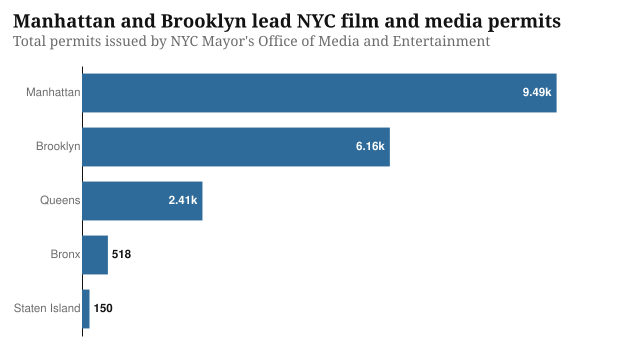

In [9]:
from IPython.display import SVG
SVG(filename='film_permit_plot.svg')